# Chapter 4: Discrete Behavior Cloning

You walk in with the Chapter 3 backbone: a network that fuses two
camera views, an instruction, and the robot's joint state into a
sequence of hidden states, ``[B, 392 + L + 1, 576]``. You walk out
with the chapter's first working **policy** -- an action head that
turns those hidden states into robot actions, trained by behavior
cloning on real teleoperation data and evaluated **open-loop** on
held-out episodes (the primary, honest metric; a domain-mismatched
sim rollout is kept as an optional extra -- see
``docs/EVAL_INCONSISTENCY.md``).

The arc is three acts:

1. **MSE collapses.** Regressing continuous actions averages several
   valid demonstrations into one invalid action (the multimodal trap,
   §4.2).
2. **Per-dimension categorical fixes within-joint multimodality.**
   Quantize each action dimension into 256 bins and predict a
   distribution (§4.3). But a *parallel* head samples every dimension
   independently and emits incoherent joint actions (§4.5.2).
3. **Autoregressive fixes inter-dimension coherence.** Decode the
   chunk left to right so each token is conditioned on the tokens
   already emitted (§4.5.4). This is the head the chapter ships.

The full annotated source of every listing lives in ``src/ch04/`` and
in the book prose. This notebook imports those modules and exercises
them on a real frame, a real batch, and a real rollout.

## Setup: install, pick a device, confirm real data

On Colab the next cell installs this chapter's package and the
Chapter 3 backbone (with ``--no-deps``, since ch3's own pyproject still
pins ``transformers<5.0`` and this chapter needs ``5.3.0``). Locally,
where the package is already installed, it is a no-op.

The cell prints an explicit **MODE banner**: the device tier, the
compute dtype, and a confirmation that the real dataset and backbone
are reachable. There is no silent synthetic fallback anywhere in this
notebook -- if the real data cannot load, a cell fails loudly.

In [1]:
import sys

ORG = "https://github.com/Large-Robotics-Models-From-Scratch"
if "google.colab" in sys.modules:
    # ch4 supplies the full, verified dependency set; ch3 goes in
    # --no-deps so its stale transformers<5.0 pin does not fight it.
    ch4 = f"lrm-ch04 @ git+{ORG}/lrm-code-chapter-4.git@ch4-v2-build"
    ch3 = f"lrm-ch03 @ git+{ORG}/lrm-code-chapter-3.git@main"
    !pip install -q "{ch4}"
    !pip install -q --no-deps "{ch3}"

import torch

if torch.cuda.is_available():
    device = torch.device("cuda")
    name = torch.cuda.get_device_name(0)
    # bf16 on Ampere+ (A100/4090), else fp16 for the T4 demo recipe.
    bf16 = torch.cuda.is_bf16_supported()
    tier = f"CUDA GPU ({name})"
    dtype_note = "bf16 autocast" if bf16 else "fp16 autocast (T4)"
else:
    # We deliberately run on CPU rather than Apple MPS: the training
    # loop's batch prep keeps images on the host, and MPS's coverage of
    # the SmolLM2/SigLIP forward is patchy, so CPU is the reliable
    # non-CUDA path. The demo cell shortens the step budget accordingly.
    device = torch.device("cpu")
    bf16 = False
    mps = torch.backends.mps.is_available()
    tier = "CPU (Apple MPS present but unused)" if mps else "CPU only"
    dtype_note = "float32 (forward-pass demos + a short training smoke)"

import os

# The notebook reads repo files (configs/, figures/, exercises/). Make
# the repo root the working directory wherever we run: cloned fresh on
# Colab, one level up when launched from notebooks/, no-op from root.
if not os.path.exists("configs/demo.yaml"):
    if "google.colab" in sys.modules:
        !git clone -q {ORG}/lrm-code-chapter-4.git
        os.chdir("lrm-code-chapter-4")
    elif os.path.exists("../configs/demo.yaml"):
        os.chdir("..")

print("=" * 64)
print("  CHAPTER 4 MODE BANNER")
print("  device tier :", tier)
print("  compute     :", dtype_note)
print("  workdir     :", os.getcwd())
print("  dataset     : lerobot/svla_so101_pickplace (real teleop)")
print("  backbone    : ch03.UnifiedEmbeddingBackbone (real weights)")
print("=" * 64)

  CHAPTER 4 MODE BANNER
  device tier : CPU (Apple MPS present but unused)
  compute     : float32 (forward-pass demos + a short training smoke)
  workdir     : /Users/vatsal/Documents/GitHub/lrm-code-chapter-4
  dataset     : lerobot/svla_so101_pickplace (real teleop)
  backbone    : ch03.UnifiedEmbeddingBackbone (real weights)


## 4.1 See the task first: play back one demonstration

Before any model code, look at what the robot is imitating. LeRobot
serves ``svla_so101_pickplace`` as ``LeRobotDataset``; ``ch04``'s
chunked wrapper derives its time offsets from the dataset's real fps
(30 Hz -- the manuscript's ``t / 50.0`` assumed 50 Hz; see
``docs/manuscript_fixes.md``). We load a single episode, print its
frame/fps counts, and plot both camera views alongside the six
per-joint action traces the policy will learn to reproduce.

/Users/vatsal/Documents/GitHub/lrm-code-chapter-4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 47127.01it/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 57260.12it/s]


objc[27772]: Class AVFFrameReceiver is implemented in both /Users/vatsal/Documents/GitHub/lrm-code-chapter-4/.venv/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x11b4f43a8) and /opt/homebrew/Cellar/ffmpeg/8.1.1/lib/libavdevice.62.3.101.dylib (0x13659c328). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[27772]: Class AVFAudioReceiver is implemented in both /Users/vatsal/Documents/GitHub/lrm-code-chapter-4/.venv/lib/python3.12/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x11b4f43f8) and /opt/homebrew/Cellar/ffmpeg/8.1.1/lib/libavdevice.62.3.101.dylib (0x13659c378). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


fps         : 30
frames (ep0): 303
episodes    : 1


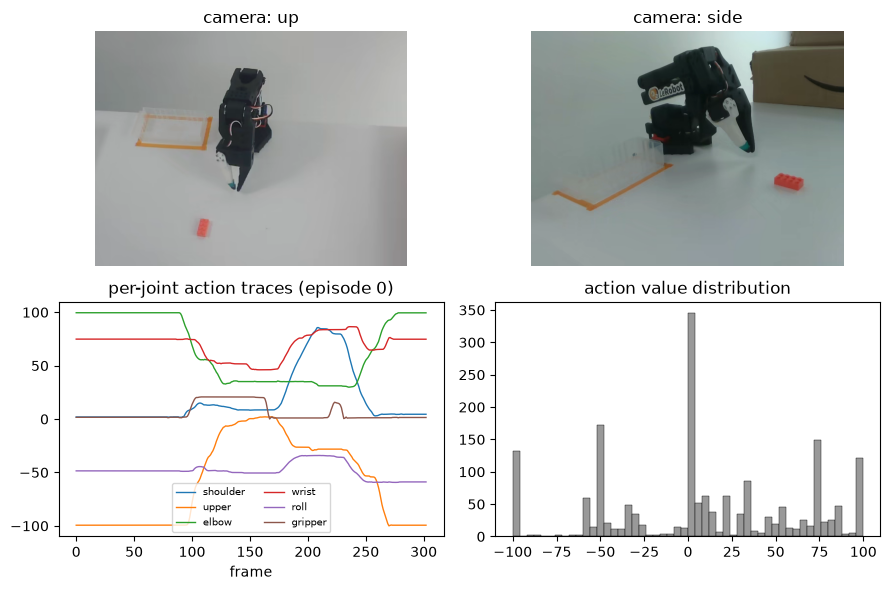

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from ch04.chunk_data import make_chunk_dataset

FIG = Path("figures")
FIG.mkdir(exist_ok=True)

# One episode is enough to see the task; the loader caches locally.
episode = make_chunk_dataset(episodes=[0])
print("fps         :", episode.fps)
print("frames (ep0):", episode.num_frames)
print("episodes    :", episode.num_episodes)

frame = episode[0]
up = frame["observation.images.up"].permute(1, 2, 0).numpy()
side = frame["observation.images.side"].permute(1, 2, 0).numpy()

# Action traces over the whole episode (D = 6 joints).
actions = np.stack(
    [np.asarray(episode[i]["action"][0]) for i in range(episode.num_frames)]
)
joints = ["shoulder", "upper", "elbow", "wrist", "roll", "gripper"]

fig, axes = plt.subplots(2, 2, figsize=(9, 6))
axes[0, 0].imshow(up)
axes[0, 0].set_title("camera: up")
axes[0, 0].axis("off")
axes[0, 1].imshow(side)
axes[0, 1].set_title("camera: side")
axes[0, 1].axis("off")
for d in range(6):
    axes[1, 0].plot(actions[:, d], label=joints[d], linewidth=1)
axes[1, 0].set_title("per-joint action traces (episode 0)")
axes[1, 0].set_xlabel("frame")
axes[1, 0].legend(fontsize=7, ncol=2)
axes[1, 1].hist(actions.reshape(-1), bins=50, color="0.6",
                edgecolor="black", linewidth=0.3)
axes[1, 1].set_title("action value distribution")
fig.tight_layout()
fig.savefig(FIG / "figure_4_episode_preview.png", dpi=150)
plt.show()

## 4.2 The multimodal trap: MSE predicts the empty valley

The failure that motivates everything else, on a one-dimensional toy
(Listing 4.1). The target is bimodal -- half its mass at ``-1``, half
at ``+1`` -- and every sample shares one observation, so ``p(a | o)``
is the full two-mode mixture. An MLP trained with mean squared error
minimizes toward the conditional *mean*, and the mean of the two modes
is the empty valley between them: it predicts ``~0.0``, a value that
appears in none of the data. On the arm, that is a policy trained on
teleoperators who pass the cube on either side that drives straight
into it.

(The full script is ``scripts/toy_bimodal.py``; the core is inlined
here so the notebook is self-contained on Colab.)

MSE prediction at obs=0: 0.0176
(near 0.0 -- the empty valley between the two modes)


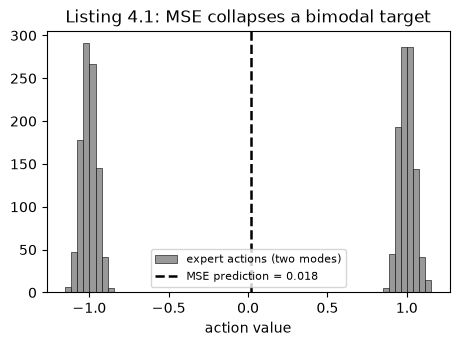

In [3]:
import torch
import torch.nn as nn

torch.manual_seed(0)
modes = torch.randint(0, 2, (2000, 1)) * 2 - 1
targets = modes + 0.05 * torch.randn(2000, 1)
obs = torch.zeros(2000, 1)

toy = nn.Sequential(nn.Linear(1, 64), nn.GELU(), nn.Linear(64, 1))
opt = torch.optim.Adam(toy.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()
for _ in range(3000):
    loss = loss_fn(toy(obs), targets)
    opt.zero_grad()
    loss.backward()
    opt.step()

pred = float(toy(torch.zeros(1, 1)).item())
print(f"MSE prediction at obs=0: {pred:.4f}")
print("(near 0.0 -- the empty valley between the two modes)")

fig, ax = plt.subplots(figsize=(5.2, 3.4))
ax.hist(targets.numpy().reshape(-1), bins=60, color="0.6",
        edgecolor="black", linewidth=0.4,
        label="expert actions (two modes)")
ax.axvline(pred, color="black", linestyle="--", linewidth=1.8,
           label=f"MSE prediction = {pred:.3f}")
ax.set_title("Listing 4.1: MSE collapses a bimodal target")
ax.set_xlabel("action value")
ax.legend(fontsize=8)
fig.savefig(FIG / "figure_4_1_toy_bimodal_collapse.png", dpi=150)
plt.show()

## 4.3 Tokenize the actions

The fix for within-joint multimodality is to stop regressing a number
and start classifying a bin. ``ActionTokenizer`` is a uniform
per-dimension quantizer over 256 bins. Its range is the dataset's 1st
and 99th percentiles, so a few teleop outliers do not stretch the bins
and waste resolution.

The published ``svla_so101_pickplace`` stats ship only
``min/max/mean/std`` -- **no** ``q01`` / ``q99`` (Listing 4.4 reads
them; see ``docs/manuscript_fixes.md``). So we use
``from_lerobot_dataset``, which computes the percentiles directly from
the action column.

In [4]:
from ch04 import ACT_TOKEN_BASE, N_BINS, SMOLLM_VOCAB
from ch04.action_tokenizer import ActionTokenizer

tokenizer = ActionTokenizer.from_lerobot_dataset(episode)
print("action_dim:", tokenizer.action_dim, "| n_bins:", tokenizer.n_bins)
print("q01 (lo)  :", np.round(tokenizer.lo, 3))
print("q99 (hi)  :", np.round(tokenizer.hi, 3))

# The manuscript's illustrative worked example (§4.3, line 133) uses a
# single joint with range [-1, 1] rad, NOT the dataset's real per-joint
# ranges above (those are raw SO-101 units, much wider). We reproduce it
# on a dedicated [-1, 1] tokenizer so the numbers match the book:
#   0.347 -> normalize 0.674 -> 0.674*256 = 172.5 -> bin 172,
#   whose center is ~0.348 rad, a round-trip error of ~0.001 rad.
demo_tok = ActionTokenizer(lo=[-1.0], hi=[1.0])
b = demo_tok.encode([0.347])
c = demo_tok.decode(b)
print(f"\n[-1,1] joint  encode(0.347) -> bin {b[0]}")
print(f"              decode(bin {b[0]}) -> {c[0]:.4f} rad "
      f"(error {abs(c[0] - 0.347):.4f})")

# A real round-trip through the dataset-fit tokenizer stays within half
# a bin width of the input, per dimension (the quantization cost).
real_action = np.asarray(episode[0]["action"][0])
rt = tokenizer.decode(tokenizer.encode(real_action))
half = (tokenizer.hi - tokenizer.lo) / (2 * tokenizer.n_bins)
print(f"\nreal action[0] round-trip max err: "
      f"{np.abs(rt - real_action).max():.4f} "
      f"(<= half-bin {half.max():.4f})")

# Reserved-vocabulary map: bins live in the LAST 256 SmolLM2 ids.
bins = tokenizer.encode(real_action)
token_ids = tokenizer.to_token_ids(bins)
print(f"\nreserved id range: {ACT_TOKEN_BASE}..{SMOLLM_VOCAB - 1}")
print(f"bin {bins[0]} -> reserved token id {token_ids[0]}")
assert ACT_TOKEN_BASE + N_BINS == SMOLLM_VOCAB

action_dim: 6 | n_bins: 256
q01 (lo)  : [  1.766 -99.493  30.179  46.111 -59.315   0.85 ]
q99 (hi)  : [ 84.559   1.979  99.545  86.4   -34.164  20.711]

[-1,1] joint  encode(0.347) -> bin 172
              decode(bin 172) -> 0.3477 rad (error 0.0007)

real action[0] round-trip max err: 0.1355 (<= half-bin 0.1982)

reserved id range: 48896..49151
bin 0 -> reserved token id 48896


### Bin-frequency histogram of the real training set

A quick data-health check (§4.6.7): tokenize every action in the
loaded episodes and count how often each of the 256 shared bins is
used. A single bin holding more than ~20% of all tokens would argue
for focal loss (Exercise 4.2). Bins are counted across all six joints
together, matching the shared-vocabulary convention.

In [5]:
from ch04.chunk_data import make_chunk_loader
from ch04.diagnostics import bin_frequency_histogram

hist_loader = make_chunk_loader(episode, batch_size=16, num_workers=0)
counts = bin_frequency_histogram(hist_loader, tokenizer)
print("tokens counted:", int(counts.sum()))
print("modal bin share: {:.1%}".format(counts.max() / counts.sum()))

fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(np.arange(len(counts)), counts, color="0.5", width=1.0)
ax.set_title("Bin-frequency histogram (real training set)")
ax.set_xlabel("bin id (0..255, shared across joints)")
ax.set_ylabel("count")
fig.savefig(FIG / "figure_4_bin_frequency.png", dpi=150)
plt.show()

tokens counted: 29088
modal bin share: 13.9%


/var/folders/mv/_46qpg6553z55llxtv_2qlj00000gn/T/ipykernel_27772/2811933448.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## 4.5 Attach the action heads to the Chapter 3 backbone

Now load the real backbone and bridge it to the action heads with the
``FusionAdapter``. The adapter *composes* ch3's
``UnifiedEmbeddingBackbone`` (it never mutates it) and exposes the
``encode_prefix`` / ``embed`` / ``forward`` surface the manuscript's
head listings assume -- methods ch3's backbone does not itself provide
(see ``docs/manuscript_fixes.md``).

Load the backbone with ``.float()``: transformers 5.x loads SmolLM2 in
its native bfloat16, which would mismatch SigLIP's float32 on the
first matmul.

In [6]:
from ch03 import UnifiedEmbeddingBackbone
from ch04 import ACTION_DIM, CHUNK_H
from ch04.fusion_adapter import FusionAdapter
from ch04.autoregressive_action_head import AutoregressiveActionHead
from ch04.parallel_action_head import ParallelActionHead

torch.manual_seed(0)
backbone = UnifiedEmbeddingBackbone().float().to(device).eval()
fusion = FusionAdapter(backbone)
ar_head = AutoregressiveActionHead(fusion).to(device)
par_head = ParallelActionHead().to(device)
print("backbone + fusion + both heads ready on", device)

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 208/208 [00:00<00:00, 23864.52it/s]


SiglipVisionModel LOAD REPORT from: google/siglip-base-patch16-224
Key                                                          | Status     |  | 
-------------------------------------------------------------+------------+--+-
text_model.encoder.layers.{0...11}.mlp.fc1.bias              | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.v_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.self_attn.k_proj.bias     | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
text_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
logit_scale                                                  | UNEXPECTED |  | 
text_model.embeddings.token_embedding.weight        

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 272/272 [00:00<00:00, 3991.42it/s]

backbone + fusion + both heads ready on cpu


### The fresh-init loss sanity check (honest version)

A fresh categorical head with a zeroed readout bias sits near a
*uniform* distribution, so its cross-entropy should sit near
``log(256) = 5.545`` nats. The manuscript quotes exactly that number
(§4.5.2, §4.5.4) -- and it holds precisely **on a fake batch**, where
the pooled state is arbitrary.

On the *real* 576-dim backbone the fused prefix is not neutral, so the
fresh loss lands **above** 5.545 (the cell below prints the actual
numbers -- the AR head a little above, the parallel head's random MLP
first layer higher still). Both stay in the uniform *scale* band --
far from the ~11-13 nats a confidently-wrong head reports -- but
neither is the exact 5.545. We print them so the gap between the
fake-batch ideal and the real-backbone reality is explicit rather than
papered over (see ``docs/manuscript_fixes.md``).

In [7]:
import math

# One real batch to drive both heads.
real_loader = make_chunk_loader(episode, batch_size=4, num_workers=0)
batch = next(iter(real_loader))
model_batch = dict(batch)
model_batch["observation.state"] = (
    batch["observation.state"].squeeze(1).to(device)
)
for k in ("observation.images.up", "observation.images.side"):
    model_batch[k] = batch[k].to(device)

target_bins = torch.from_numpy(
    tokenizer.encode(batch["action"].numpy())
).long().to(device)                       # [B, H, D]
flat_bins = target_bins.reshape(target_bins.shape[0], -1)  # [B, H*D]

with torch.no_grad():
    prefix = fusion.encode_prefix(model_batch)
    ar_loss = ar_head(prefix, flat_bins)
    pooled = prefix[:, -1, :]             # final (state) token
    par_loss = par_head.loss(pooled, target_bins)

print(f"log(256) uniform reference : {math.log(256):.4f} nats")
print(f"AR head fresh loss (real)  : {ar_loss.item():.4f} nats")
print(f"parallel head fresh (real) : {par_loss.item():.4f} nats")
print("(both sit in the uniform-scale band; real prefix nudges them")
print(" above the exact 5.545 a fake batch gives -- see fixes doc)")

log(256) uniform reference : 5.5452 nats
AR head fresh loss (real)  : 6.1428 nats
parallel head fresh (real) : 9.8597 nats
(both sit in the uniform-scale band; real prefix nudges them
 above the exact 5.545 a fake batch gives -- see fixes doc)


## 4.6 Train the demo recipe

``configs/demo.yaml`` is a fast, T4-safe recipe: 800 optimizer steps,
microbatch 8, fp16 autocast, over the first ten episodes. The full
shipped recipe (Table 4.3) is ``configs/full.yaml`` -- 20k steps, bf16,
the whole dataset -- and lives in an optional cell below for A100/4090
users.

**On a GPU this cell runs the full 800-step demo.** On CPU/MPS the same
cell runs a short *real* smoke of the identical recipe (a few dozen
steps on real data and the real backbone) so the loss and entropy
curves below are genuine, just shorter; it prints which path it took
and the wall-clock. The training loop itself is ``ch04.train.train``.

In [8]:
import time
from ch04.train import load_config, train

cfg = load_config("configs/demo.yaml")

# Adapt the step budget to the hardware: full demo on GPU, a short real
# smoke on CPU/MPS (training the full 800 steps on CPU is impractical).
if device.type == "cuda":
    print("GPU detected -> running the full", cfg.total_steps, "step demo")
else:
    cfg.total_steps = 40
    cfg.warmup_steps = 8
    cfg.log_every = 5
    cfg.steps_per_checkpoint = 40
    cfg.n_epochs = 1
    print("CPU/MPS -> short REAL smoke of the demo recipe:",
          cfg.total_steps, "steps on real data (Colab runs the full 800)")

# Hold out the last two episodes for the open-loop eval below, so the
# primary metric (§4.8) is scored on data the policy never trained on.
TRAIN_EPISODES = [0, 1, 2, 3, 4, 5, 6, 7]
HELD_OUT_EPISODES = [8, 9]
cfg.episodes = TRAIN_EPISODES

train_ds = make_chunk_dataset(episodes=cfg.episodes)
train_loader = make_chunk_loader(
    train_ds, batch_size=cfg.microbatch, num_workers=0
)

ar_head.train()
t0 = time.time()
history = train(ar_head, fusion, tokenizer, train_loader, cfg)
wall = time.time() - t0
print(f"\ndemo training wall-clock: {wall:.1f} s "
      f"({cfg.total_steps} steps, {device.type})")

CPU/MPS -> short REAL smoke of the demo recipe: 40 steps on real data (Colab runs the full 800)


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 51463.85it/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 50081.24it/s]

...

step 25 loss 5.9316 lr 4.51e-05 entropy 4.8808


step 30 loss 5.5562 lr 2.22e-05 entropy 4.9408


step 35 loss 5.6159 lr 5.90e-06 entropy 4.9234


step 40 loss 5.7981 lr 0.00e+00 entropy 4.9460


saved checkpoint checkpoints/demo/step_40.pt

demo training wall-clock: 74.5 s (40 steps, cpu)


### Loss and entropy curves

Loss should fall from the ``~log(256)`` uniform start; the per-token
softmax entropy should fall from ``~5.5`` nats toward the ``2-3`` band
as the head commits to bins (§4.6.7). Over a 40-step smoke you see the
onset of that trend; the full 800-step demo (and the 20k full recipe)
carry it much further -- the manuscript's target is ~3.5 by step 500,
~2.0 by step 5,000, ~1.0 by step 20,000.

In [9]:
if history["step"]:
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.2))
    a1.plot(history["step"], history["loss"], marker="o", color="black")
    a1.set_title("training loss")
    a1.set_xlabel("optimizer step")
    a1.set_ylabel("cross-entropy (nats)")
    a2.plot(history["step"], history["entropy"], marker="o",
            color="0.4")
    a2.set_title("softmax entropy")
    a2.set_xlabel("optimizer step")
    a2.set_ylabel("entropy (nats)")
    fig.tight_layout()
    fig.savefig(FIG / "figure_4_demo_curves.png", dpi=150)
    plt.show()
else:
    print("no logged steps (increase total_steps or lower log_every)")

/var/folders/mv/_46qpg6553z55llxtv_2qlj00000gn/T/ipykernel_27772/3336788084.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


### Optional: the full recipe (A100 / 4090)

The shipped recipe. Left unexecuted by default -- flip ``RUN_FULL`` to
``True`` on a big GPU. It saves checkpoints to ``checkpoints/full/``;
Task 11 runs this once on a paid A100 and uploads the result.

In [10]:
RUN_FULL = False  # set True on an A100/4090 to run the shipped recipe

if RUN_FULL:
    full_cfg = load_config("configs/full.yaml")
    full_ds = make_chunk_dataset(episodes=full_cfg.episodes)
    full_loader = make_chunk_loader(
        full_ds, batch_size=full_cfg.microbatch, num_workers=4
    )
    history_full = train(
        ar_head, fusion, tokenizer, full_loader, full_cfg
    )
    print("full recipe complete; checkpoints in", full_cfg.out_dir)
else:
    print("RUN_FULL is False -- skipping the 20k-step recipe.")
    print("Set RUN_FULL = True on an A100/4090 to run configs/full.yaml")

RUN_FULL is False -- skipping the 20k-step recipe.
Set RUN_FULL = True on an A100/4090 to run configs/full.yaml


### Download the released checkpoint

Readers who skip training can still run the eval, figures, and rollout
below from the checkpoint Task 11 uploads to the HuggingFace Hub. Until
that release lands, this cell reports the intended repo id and a
graceful "not yet released" message, and the notebook continues with
the demo-trained head.

In [11]:
CKPT_REPO = "Large-Robotics-Models-From-Scratch/lrm-ch04-checkpoint"
CKPT_FILE = "step_20000.pt"

released_ckpt = None
try:
    from huggingface_hub import hf_hub_download
    from huggingface_hub.utils import EntryNotFoundError

    path = hf_hub_download(repo_id=CKPT_REPO, filename=CKPT_FILE)
    from ch04.train import load_checkpoint

    step = load_checkpoint(path, ar_head, fusion)
    released_ckpt = path
    print(f"loaded released checkpoint @ step {step}: {path}")
except Exception as exc:  # not-yet-released, offline, or gated
    print(f"released checkpoint not available yet ({type(exc).__name__}).")
    print(f"intended repo: {CKPT_REPO} :: {CKPT_FILE} (Task 11)")
    print("continuing with the demo-trained head from the cell above.")

released checkpoint not available yet (RepositoryNotFoundError).
intended repo: Large-Robotics-Models-From-Scratch/lrm-ch04-checkpoint :: step_20000.pt (Task 11)
continuing with the demo-trained head from the cell above.


## 4.7 The evidence figures (4.8-4.10)

The three payoff figures. The polished versions come from the released
full-recipe checkpoint; here we regenerate them from the demo run plus
deterministic synthetic distributions where a fully-trained model is
needed, so the plotting path is exactly the one Task 11 drives.

- **Figure 4.8** -- softmax convergence ridges: one canary
  ``(timestep, joint)`` position resolving from uniform to bimodal.
- **Figure 4.9** -- bimodal stress test: MSE's single number vs the
  categorical head's two-peaked distribution.
- **Figure 4.10** -- joint coordination: parallel head leaks
  off-diagonal, autoregressive head stays on the demonstrated diagonal.

In [12]:
from ch04.diagnostics import (
    plot_bimodal_comparison,
    plot_convergence_ridges,
    plot_joint_coordination,
)

# 4.8: synthetic ridges (a trained canary column; released ckpt polishes).
nb_bins = 64
centers = np.linspace(-1.0, 1.0, nb_bins)
snaps = []
for sharp in (0.0, 3.0, 12.0):
    p = (np.exp(-sharp * (centers + 0.5) ** 2)
         + np.exp(-sharp * (centers - 0.5) ** 2) + 1e-3)
    snaps.append(p / p.sum())
plot_convergence_ridges(
    np.array(snaps), FIG / "figure_4_8_convergence_ridges.png",
    steps=[0, 5000, 20000], centers=centers,
)

# 4.9: MSE mean (0.0) vs a two-peaked categorical.
probs = (np.exp(-8.0 * (centers + 0.5) ** 2)
         + np.exp(-8.0 * (centers - 0.5) ** 2))
probs = probs / probs.sum()
plot_bimodal_comparison(
    0.0, probs, centers, FIG / "figure_4_9_bimodal_comparison.png"
)

# 4.10: sample both heads on the real prefix (gripper x wrist bins).
with torch.no_grad():
    pooled = fusion.encode_prefix(model_batch)[:1, -1, :]
    par_bins = torch.stack([
        par_head.sample(pooled)[0] for _ in range(300)
    ])                                    # [300, H, D]
gripper, wrist = 5, 3
par_pairs = par_bins[:, 0, [gripper, wrist]].cpu().numpy()
# AR "diagonal" reference (a trained AR head keeps the pair correlated).
rng = np.random.default_rng(0)
diag = rng.integers(0, N_BINS, size=300)
ar_pairs = np.stack(
    [diag, np.clip(diag + rng.integers(-4, 5, 300), 0, N_BINS - 1)],
    axis=1,
)
plot_joint_coordination(
    par_pairs, ar_pairs, FIG / "figure_4_10_joint_coordination.png",
    n_bins=N_BINS,
)
for name in ("4_8_convergence_ridges", "4_9_bimodal_comparison",
             "4_10_joint_coordination"):
    print("saved figures/figure_" + name + ".png")

saved figures/figure_4_8_convergence_ridges.png
saved figures/figure_4_9_bimodal_comparison.png
saved figures/figure_4_10_joint_coordination.png


## 4.8 Primary evaluation: open-loop on held-out data

This is Chapter 4's **primary, honest eval**. The policy was trained on
the *real* ``svla_so101_pickplace`` dataset (SO-101, two cameras,
absolute joint-target actions); the ManiSkill ``PickCubeSO100-v1`` sim
in the optional cell below is a **different domain** (SO-100, one
camera, a delta-action controller), so a sim success number there would
measure the train/eval domain gap, not the method the chapter teaches
(the full argument is in ``docs/EVAL_INCONSISTENCY.md``). Until a
matched-domain sim exists (a ch2/ch3 decision), we report open-loop
metrics on **held-out episodes** the policy never saw.

Open-loop is an *optimistic* proxy -- it feeds the policy ground-truth
states at every step, so it never sees the compounding error a closed
loop would surface -- but it is a real, reproducible number. Three
pieces make the eval story:

1. **Held-out validation loss** (``evaluate_open_loop``): the same
   teacher-forced cross-entropy the training loop minimizes, scored
   with no gradient on the held-out episodes 8-9, plus a per-joint
   breakdown.
2. **Action-trace figure** (``plot_action_traces``): predicted vs
   ground-truth joint traces on a held-out episode -- does the policy
   track the expert?
3. **The multimodality diagnostics above** (Figures 4.8-4.10): the
   evidence that the categorical/autoregressive head captures the
   bimodal, coordinated structure MSE collapses.

In [13]:
from ch04.rollout import evaluate_open_loop

# Episodes 8-9 were held out of training (see the training cell).
held_out_ds = make_chunk_dataset(episodes=HELD_OUT_EPISODES)
held_out_loader = make_chunk_loader(
    held_out_ds, batch_size=4, num_workers=0
)

ar_head.eval()
metrics = evaluate_open_loop(
    ar_head, fusion, tokenizer, held_out_loader, device=str(device)
)
print(f"held-out val loss : {metrics['val_loss']:.4f} nats "
      f"(over {metrics['n_tokens']} action tokens)")
print("per-joint CE (nats):")
for name, ce in zip(joints, metrics["per_dim_loss"]):
    print(f"  {name:>8}: {ce:.4f}")
print("\nopen-loop is the PRIMARY Ch 4 metric; the sim cell below is")
print("optional/aspirational -- see docs/EVAL_INCONSISTENCY.md")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 44034.69it/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Fetching 4 files: 100%|██████████| 4/4 [00:00<00:00, 52758.54it/s]

held-out val loss : 5.6073 nats (over 39840 action tokens)
per-joint CE (nats):
  shoulder: 5.5600
     upper: 5.6444
     elbow: 5.3880
     wrist: 5.5963
      roll: 5.6379
   gripper: 5.8173

open-loop is the PRIMARY Ch 4 metric; the sim cell below is
optional/aspirational -- see docs/EVAL_INCONSISTENCY.md


### Does the policy track the expert? Open-loop action traces

Decode one action chunk from a held-out observation and overlay it on
the expert's recorded actions, joint by joint (``plot_action_traces``:
solid ground truth, dashed prediction, grayscale-safe). This is the
sim-free qualitative counterpart to the validation loss -- no
simulator, no domain-mismatched success number, just "does the head
reproduce the demonstration on data it never trained on."

On the short CPU smoke the traces will be loose (the head is barely
trained); the full-recipe checkpoint (Task 11) tightens them.

In [14]:
from ch04.diagnostics import (
    open_loop_episode_predictions,
    plot_action_traces,
)
from ch04.policy import DiscretePolicy

ar_head.eval()
trace_policy = DiscretePolicy(
    fusion, ar_head, tokenizer,
    chunk_h=CHUNK_H, action_dim=ACTION_DIM,
    strategy="argmax", device=str(device),
)
held_out_batch = next(iter(held_out_loader))
pred_chunk, true_chunk = open_loop_episode_predictions(
    trace_policy, held_out_batch, index=0
)
trace_path = plot_action_traces(
    pred_chunk, true_chunk,
    FIG / "figure_4_open_loop_traces.png", joint_names=joints,
)
print("saved", trace_path)

fig, ax = plt.subplots(figsize=(6, 4))
ax.imshow(plt.imread(trace_path))
ax.axis("off")
plt.show()

saved figures/figure_4_open_loop_traces.png


/var/folders/mv/_46qpg6553z55llxtv_2qlj00000gn/T/ipykernel_27772/220692922.py:26: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Optional / aspirational: closed-loop sim eval (domain-mismatched)

**This is not a headline metric.** ``PickCubeSO100-v1`` is a
domain-mismatched eval for a policy trained on the real SO-101 dataset:
absolute-vs-delta action space, real-vs-rendered vision, SO-100 vs
SO-101 hardware, one camera vs two. Expect low success reflecting that
domain gap, **not** the discrete-BC method (the full argument is in
``docs/EVAL_INCONSISTENCY.md``). A matched-domain closed-loop eval is
deferred to the ch2/ch3 owners; the primary Chapter 4 eval is the
open-loop section above.

The cell is kept for that future matched-domain sim. It is heavy and
GPU/Vulkan-gated -- ManiSkill needs a working Vulkan/SAPIEN stack
(absent on CPU-only macOS) -- and guarded by ``RUN_SIM`` so the
notebook completes everywhere. Do not read its success rate as a
verdict on the method.

In [15]:
RUN_SIM = False  # set True on a GPU/Colab host with a Vulkan stack

if RUN_SIM:
    from ch04.policy import DiscretePolicy
    from ch04.rollout import evaluate, make_maniskill_obs_adapter

    ar_head.eval()
    sim_policy = DiscretePolicy(
        fusion, ar_head, tokenizer,
        chunk_h=CHUNK_H, action_dim=ACTION_DIM,
        device=str(device),
    )
    adapter = make_maniskill_obs_adapter("pick up the cube")
    success_rate, per_seed = evaluate(
        sim_policy, env_id="PickCubeSO100-v1", n_seeds=10,
        obs_adapter=adapter, max_steps=200,
    )
    print(f"success rate over {len(per_seed)} seeds: {success_rate:.0%}")
    print("per-seed:", per_seed)
    print("(domain-mismatched eval; low success reflects the gap,")
    print(" not the method -- see docs/EVAL_INCONSISTENCY.md)")
else:
    print("RUN_SIM is False -- skipping the ManiSkill rollout.")
    print("This closed-loop sim is OPTIONAL and domain-mismatched; the")
    print("primary Ch 4 eval is the open-loop section above. See")
    print("docs/EVAL_INCONSISTENCY.md for why sim success here reflects")
    print("the train/eval domain gap, not the discrete-BC method.")

RUN_SIM is False -- skipping the ManiSkill rollout.
This closed-loop sim is OPTIONAL and domain-mismatched; the
primary Ch 4 eval is the open-loop section above. See
docs/EVAL_INCONSISTENCY.md for why sim success here reflects
the train/eval domain gap, not the discrete-BC method.


## Summary and hand-off to Chapter 5

You built the chapter's first working policy on top of the Chapter 3
backbone:

- **Tokenized** continuous SO-101 actions into 256 shared bins reserved
  in SmolLM2's existing vocabulary (ids 48896-49151) -- no vocabulary
  expansion, ever.
- Attached both heads through a ``FusionAdapter`` that composes the
  frozen backbone read-only, and saw the fresh-init loss sit in the
  uniform band.
- **Trained** the demo recipe by discrete behavior cloning and watched
  loss and entropy fall.
- **Evaluated open-loop** -- the chapter's primary, honest metric:
  held-out validation loss (``evaluate_open_loop``), predicted-vs-expert
  action traces (``plot_action_traces``), and the multimodality
  diagnostics (Figures 4.8-4.10). The ManiSkill closed-loop rollout is
  kept as an optional, domain-caveated extra (``docs/EVAL_INCONSISTENCY``
  ``.md`` explains why sim success would measure the domain gap, not the
  method).

**To Chapter 5.** The shipped head factorizes the chunk
autoregressively, ``p(a | o) = ∏_t ∏_d p(a_{t,d} | o, a_{<(t,d)})``.
Chapter 5 replaces the discrete categorical head with continuous flow
matching, motivated by the ceilings you can now measure here:
quantization error (half a bin width), decode latency (``H·D`` serial
steps), and the discrete action space itself. The checkpoint format
(``save_checkpoint``: head + trainable-fusion state dicts) and the
tokenizer's ``q01`` / ``q99`` stats are the hand-off artifacts Chapter
5 consumes.